# RAGAS Results Analysis

This notebook loads RAGAS evaluation outputs and the FAQ golden dataset, enriches the results with section metadata, and produces cleaner, report-ready visualisations for comparing RAG pipeline experiments.

It is designed to work directly with the uploaded files:
- `ragas_config_results.json`
- `ucd_studentdesk_faqs.json`


In [30]:

from pathlib import Path
import json
import textwrap

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from IPython.display import display, Markdown

# Plot style
sns.set_theme(style="whitegrid", context="talk")
plt.rcParams["figure.dpi"] = 120
plt.rcParams["axes.spines.top"] = False
plt.rcParams["axes.spines.right"] = False

# Use the current working directory by default
BASE_DIR = Path.cwd()

def resolve_existing_path(candidates):
    for candidate in candidates:
        candidate = Path(candidate)
        if candidate.exists():
            return candidate
    raise FileNotFoundError(
        "Could not find the required input files.\n"
        "Update RESULTS_JSON and FAQ_JSON so they point to the correct files on your machine."
    )

# Try a few common local layouts
# RESULTS_JSON = resolve_existing_path([
#     BASE_DIR / "ragas_config_results.json",
#     BASE_DIR / "ragas_results" / "ragas_config_results.json",
# ])

# Try a few common local layouts
RESULTS_JSON = resolve_existing_path([
    BASE_DIR / "ragas_config_results_dynamic.json",
    BASE_DIR / "ragas_results" / "ragas_config_results_dynamic.json",
])

FAQ_JSON = resolve_existing_path([
    BASE_DIR / "ucd_studentdesk_faqs.json",
    BASE_DIR / "data" / "datasets" / "ucd_studentdesk_faqs.json",
])

OUTPUT_DIR = BASE_DIR / "ragas_analysis_outputs"
OUTPUT_DIR.mkdir(exist_ok=True)

pd.set_option("display.max_columns", 100)
pd.set_option("display.max_colwidth", 120)

METRIC_COLS = [
    "faithfulness",
    "answer_correctness",
    "answer_relevancy",
    "context_precision",
    "context_recall",
]

PRIMARY_METRICS = [
    "faithfulness",
    "answer_correctness",
    "answer_relevancy",
]

MODEL_ORDER = ["First model", "Best model"]
MODEL_PALETTE = {
    "First model": "#4C72B0",
    "Best model": "#DD8452",
}

print("BASE_DIR:", BASE_DIR)
print("RESULTS_JSON:", RESULTS_JSON)
print("FAQ_JSON:", FAQ_JSON)
print("OUTPUT_DIR:", OUTPUT_DIR)


BASE_DIR: c:\Users\eoinm\masters\group_assignments\semester-2\COMP41860-dashboard\backend
RESULTS_JSON: c:\Users\eoinm\masters\group_assignments\semester-2\COMP41860-dashboard\backend\ragas_results\ragas_config_results_dynamic.json
FAQ_JSON: c:\Users\eoinm\masters\group_assignments\semester-2\COMP41860-dashboard\backend\data\datasets\ucd_studentdesk_faqs.json
OUTPUT_DIR: c:\Users\eoinm\masters\group_assignments\semester-2\COMP41860-dashboard\backend\ragas_analysis_outputs


## Load the RAGAS results and FAQ metadata

In [31]:
def load_json(path: Path):
    with open(path, "r", encoding="utf-8") as f:
        return json.load(f)

results_config = load_json(RESULTS_JSON)
faq_data = load_json(FAQ_JSON)

print(f"Experiments loaded: {len(results_config['experiments'])}")
print(f"FAQ items loaded: {len(faq_data)}")

Experiments loaded: 2
FAQ items loaded: 80


In [32]:
faq_df = pd.DataFrame(faq_data)
faq_df = faq_df.rename(columns={"id": "faq_id"})
faq_df["question_normalized"] = faq_df["question"].str.strip().str.lower()

faq_lookup = faq_df[[
    "question",
    "question_normalized",
    "section",
    "section_order",
    "question_order",
    "faq_id",
]]

faq_lookup.head()

,question,question_normalized,section,section_order,question_order,faq_id
0,"How do I log in to UCD IT Systems including SISWeb, Brightspace or UCD Email?","how do i log in to ucd it systems including sisweb, brightspace or ucd email?",UCD Connect,1,1,06015524abfb12e15ae01220483b6705b73c6679
1,What is SISWeb? What is Brightspace?,what is sisweb? what is brightspace?,UCD Connect,1,2,d5d545c772a11ec1f5295a7d95a76f7935782acf
2,How do I reset my password?,how do i reset my password?,UCD Connect,1,3,cd64d1632af8dfa4b824b30699085f22c8ddfcc8
3,How do I contact IT Support Hub?,how do i contact it support hub?,UCD Connect,1,4,8cb347ec9dac24845315f4ebbf10b1c477a1e540
4,Will I lose access to SISWeb when I graduate or if I leave UCD?,will i lose access to sisweb when i graduate or if i leave ucd?,UCD Connect,1,5,bea52bd424329a64f9c5eeca6f600314c2639896


In [33]:

rows = []
for exp in results_config["experiments"]:
    for result in exp["results"]:
        rows.append({
            "experiment_name": exp["experiment_name"],
            "llm_model": exp["llm_model"],
            "embedding_model": exp["embedding_model"],
            "retriever_k": exp["retriever_k"],
            **result
        })

df = pd.DataFrame(rows)
df["question_normalized"] = df["question"].str.strip().str.lower()

df = df.merge(
    faq_lookup.drop(columns=["question"]),
    on="question_normalized",
    how="left",
)

df["section"] = df["section"].fillna("Unknown")
df["section_order"] = df["section_order"].fillna(999).astype(int)
df["latency_s"] = df["latency_ms"] / 1000

# Compact experiment names for internal comparisons
experiment_name_map = {
    name: f"Exp {i+1}"
    for i, name in enumerate(df["experiment_name"].drop_duplicates())
}
df["experiment_short"] = df["experiment_name"].map(experiment_name_map)

# Reader-friendly labels for plots and tables
label_map = {
    "Exp 1": "First model",
    "Exp 2": "Best model"
}
df["experiment_label"] = df["experiment_short"].map(label_map).fillna(df["experiment_short"])

# More descriptive metadata if needed later
df["experiment_descriptor"] = (
    df["llm_model"]
    + " | "
    + df["embedding_model"]
    + " | k="
    + df["retriever_k"].astype(str)
)

display(df.head())
print(df.shape)


,experiment_name,llm_model,embedding_model,retriever_k,question,faithfulness,answer_correctness,answer_relevancy,context_precision,context_recall,latency_ms,question_normalized,section,section_order,question_order,faq_id,latency_s,experiment_short,experiment_label,experiment_descriptor
0,voyageai_512_64_basic_dense_False,llama3.2:3b,nomic-embed-text,4,"How do I log in to UCD IT Systems including SISWeb, Brightspace or UCD Email?",0.620,0.629,0.437,0.555,0.403,1938,"how do i log in to ucd it systems including sisweb, brightspace or ucd email?",UCD Connect,1,1,06015524abfb12e15ae01220483b6705b73c6679,1.938,Exp 1,First model,llama3.2:3b | nomic-embed-text | k=4
1,voyageai_512_64_basic_dense_False,llama3.2:3b,nomic-embed-text,4,What is SISWeb? What is Brightspace?,0.743,0.728,0.641,0.618,0.617,2055,what is sisweb? what is brightspace?,UCD Connect,1,2,d5d545c772a11ec1f5295a7d95a76f7935782acf,2.055,Exp 1,First model,llama3.2:3b | nomic-embed-text | k=4
2,voyageai_512_64_basic_dense_False,llama3.2:3b,nomic-embed-text,4,How do I reset my password?,0.455,0.710,0.607,0.451,0.316,1546,how do i reset my password?,UCD Connect,1,3,cd64d1632af8dfa4b824b30699085f22c8ddfcc8,1.546,Exp 1,First model,llama3.2:3b | nomic-embed-text | k=4
3,voyageai_512_64_basic_dense_False,llama3.2:3b,nomic-embed-text,4,How do I contact IT Support Hub?,0.586,0.599,0.619,0.475,0.564,1858,how do i contact it support hub?,UCD Connect,1,4,8cb347ec9dac24845315f4ebbf10b1c477a1e540,1.858,Exp 1,First model,llama3.2:3b | nomic-embed-text | k=4
4,voyageai_512_64_basic_dense_False,llama3.2:3b,nomic-embed-text,4,Will I lose access to SISWeb when I graduate or if I leave UCD?,0.719,0.498,0.676,0.561,0.425,2059,will i lose access to sisweb when i graduate or if i leave ucd?,UCD Connect,1,5,bea52bd424329a64f9c5eeca6f600314c2639896,2.059,Exp 1,First model,llama3.2:3b | nomic-embed-text | k=4


(160, 20)


## Save cleaned analysis tables

In [34]:

df.to_csv(OUTPUT_DIR / "all_ragas_results_enriched.csv", index=False)

summary_df = (
    df.groupby(
        ["experiment_name", "experiment_short", "experiment_label", "llm_model", "embedding_model", "retriever_k"],
        as_index=False
    )[METRIC_COLS + ["latency_ms", "latency_s"]]
      .mean()
      .sort_values("answer_correctness", ascending=False)
)

summary_df.to_csv(OUTPUT_DIR / "experiment_summary.csv", index=False)

display(summary_df.round(3))


,experiment_name,experiment_short,experiment_label,llm_model,embedding_model,retriever_k,faithfulness,answer_correctness,answer_relevancy,context_precision,context_recall,latency_ms,latency_s
1,voyageai_512_64_contextual_hybrid_True,Exp 2,Best model,phi3:mini,mxbai-embed-large,6,0.942,0.908,0.88,0.867,0.868,1638.262,1.638
0,voyageai_512_64_basic_dense_False,Exp 1,First model,llama3.2:3b,nomic-embed-text,4,0.594,0.578,0.58,0.512,0.468,1951.500,1.952


## Dataset overview

In [35]:
overview = pd.DataFrame({
    "n_experiments": [df["experiment_name"].nunique()],
    "n_questions": [df["question"].nunique()],
    "n_rows": [len(df)],
    "n_sections": [df["section"].nunique()],
})
display(overview)

,n_experiments,n_questions,n_rows,n_sections
0,2,80,160,13


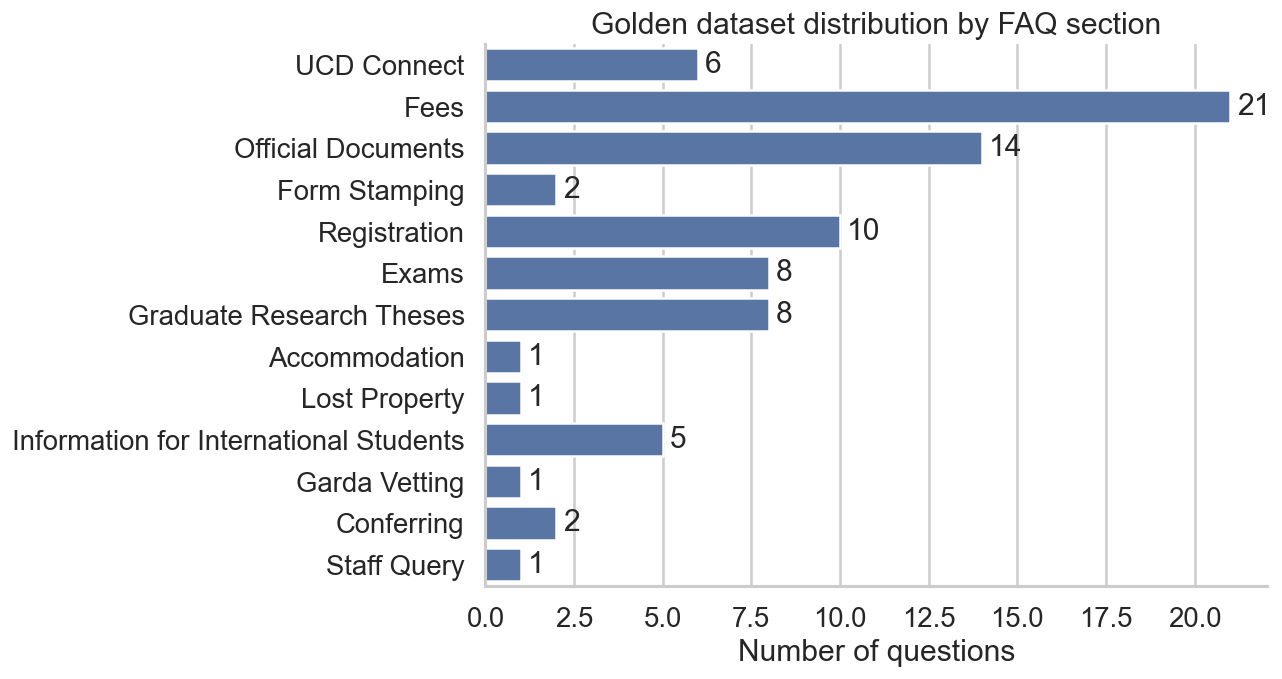

,section_order,section,size
0,1,UCD Connect,6
1,2,Fees,21
2,3,Official Documents,14
3,4,Form Stamping,2
4,5,Registration,10
5,6,Exams,8
6,7,Graduate Research Theses,8
7,8,Accommodation,1
8,9,Lost Property,1
9,10,Information for International Students,5


In [36]:
section_counts = (
    faq_df.groupby(["section_order", "section"], as_index=False)
          .size()
          .sort_values(["section_order", "section"])
)

fig, ax = plt.subplots(figsize=(11, 6))
sns.barplot(data=section_counts, y="section", x="size", ax=ax)
ax.set_title("Golden dataset distribution by FAQ section")
ax.set_xlabel("Number of questions")
ax.set_ylabel("")
for container in ax.containers:
    ax.bar_label(container, padding=4)
plt.tight_layout()
plt.show()

section_counts

## Overall experiment comparison

In [37]:

display(
    summary_df[[
        "experiment_label",
        "experiment_name",
        "llm_model",
        "embedding_model",
        "retriever_k",
        *METRIC_COLS,
        "latency_s",
    ]].round(3)
)


,experiment_label,experiment_name,llm_model,embedding_model,retriever_k,faithfulness,answer_correctness,answer_relevancy,context_precision,context_recall,latency_s
1,Best model,voyageai_512_64_contextual_hybrid_True,phi3:mini,mxbai-embed-large,6,0.942,0.908,0.88,0.867,0.868,1.638
0,First model,voyageai_512_64_basic_dense_False,llama3.2:3b,nomic-embed-text,4,0.594,0.578,0.58,0.512,0.468,1.952


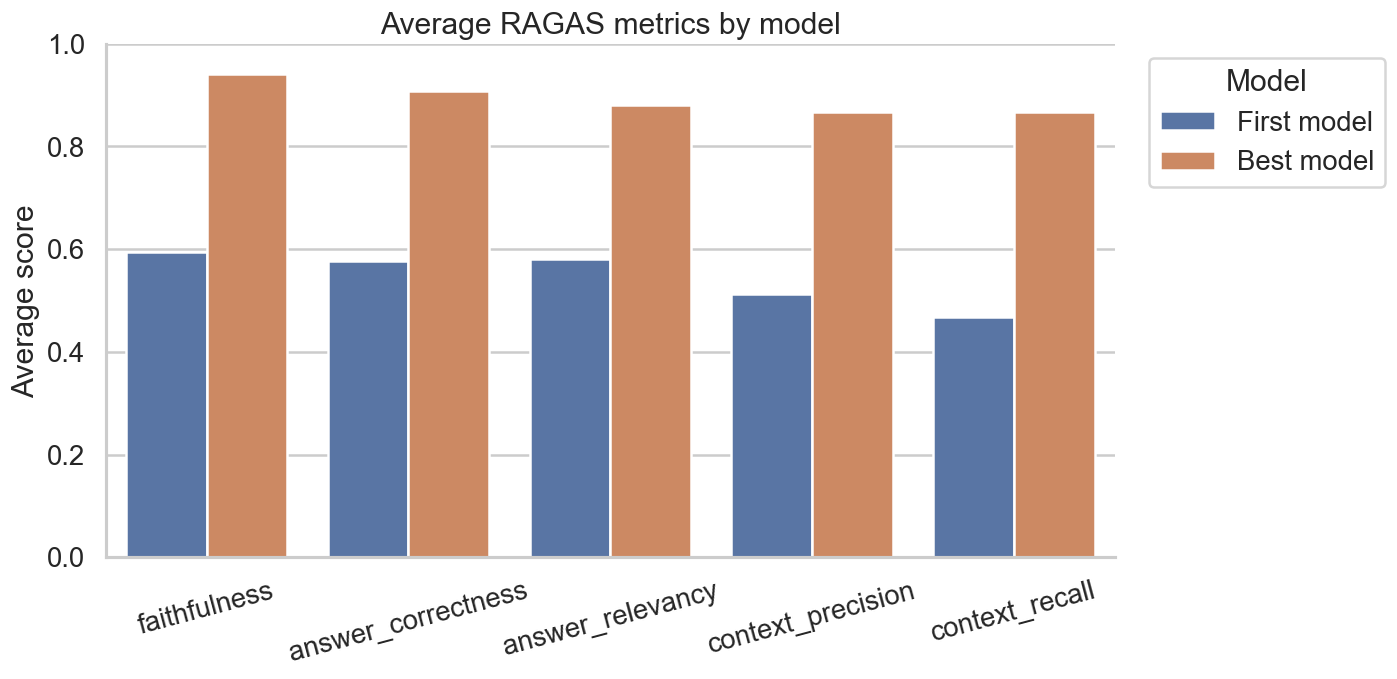

In [38]:

plot_summary = summary_df.melt(
    id_vars=["experiment_label"],
    value_vars=METRIC_COLS,
    var_name="metric",
    value_name="score",
)

fig, ax = plt.subplots(figsize=(12, 6))
sns.barplot(
    data=plot_summary,
    x="metric",
    y="score",
    hue="experiment_label",
    hue_order=MODEL_ORDER,
    palette=MODEL_PALETTE,
    ax=ax
)
ax.set_title("Average RAGAS metrics by model")
ax.set_xlabel("")
ax.set_ylabel("Average score")
ax.set_ylim(0, 1)
ax.legend(title="Model", bbox_to_anchor=(1.02, 1), loc="upper left")
plt.xticks(rotation=15)
plt.tight_layout()
plt.show()


C:\Users\eoinm\AppData\Local\Temp\ipykernel_11436\107514242.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(
C:\Users\eoinm\AppData\Local\Temp\ipykernel_11436\107514242.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(
C:\Users\eoinm\AppData\Local\Temp\ipykernel_11436\107514242.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(


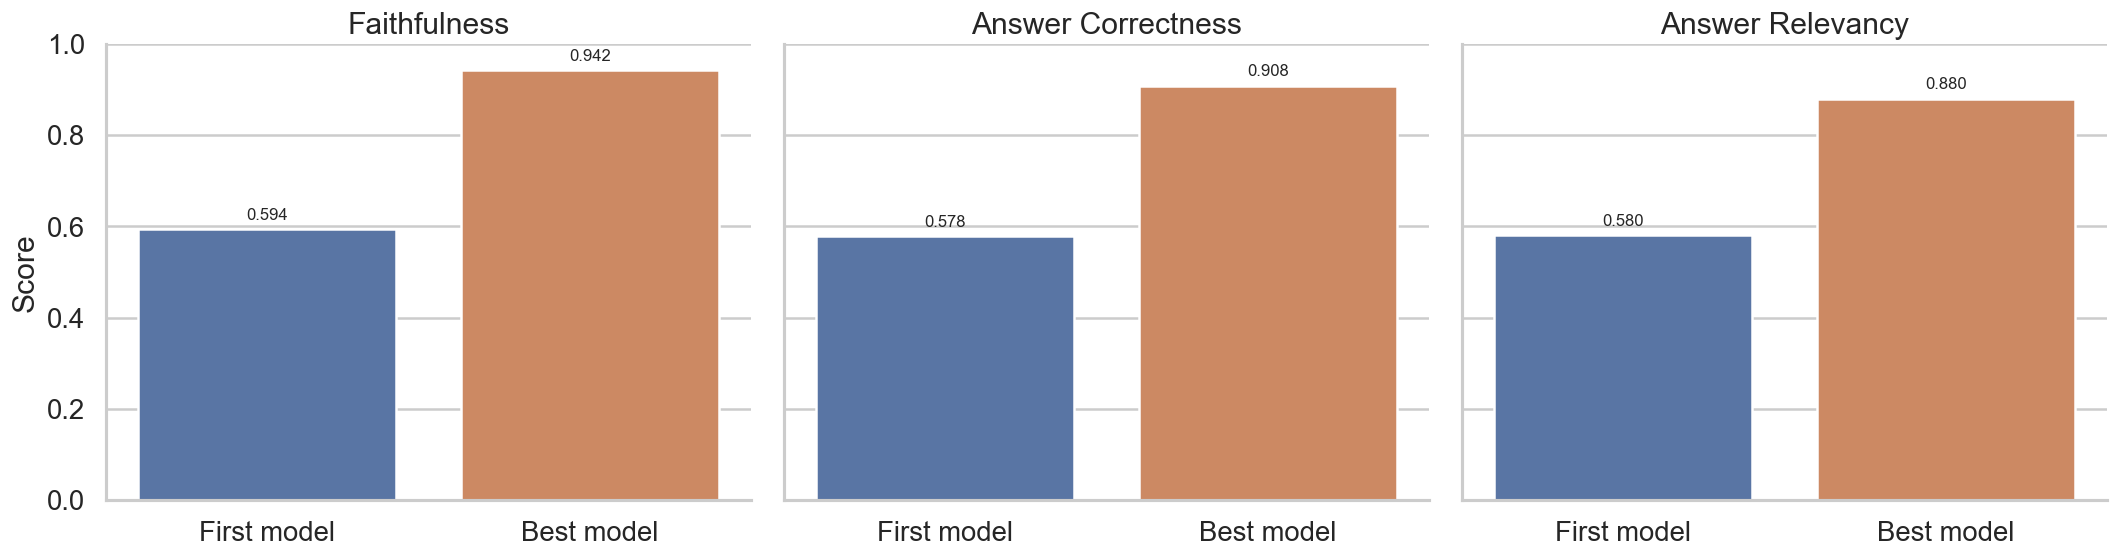

In [39]:

fig, axes = plt.subplots(1, len(PRIMARY_METRICS), figsize=(18, 5), sharey=True)

for ax, metric in zip(axes, PRIMARY_METRICS):
    sns.barplot(
        data=summary_df,
        x="experiment_label",
        y=metric,
        order=MODEL_ORDER,
        palette=MODEL_PALETTE,
        ax=ax,
        errorbar=None
    )
    ax.set_title(metric.replace("_", " ").title())
    ax.set_xlabel("")
    ax.set_ylabel("Score")
    ax.set_ylim(0, 1)
    for container in ax.containers:
        ax.bar_label(container, fmt="%.3f", padding=4, fontsize=10)

plt.tight_layout()
plt.show()


## Distribution plots

C:\Users\eoinm\AppData\Local\Temp\ipykernel_11436\1002830685.py:23: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  ax.legend(title="Model")
C:\Users\eoinm\AppData\Local\Temp\ipykernel_11436\1002830685.py:23: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  ax.legend(title="Model")
C:\Users\eoinm\AppData\Local\Temp\ipykernel_11436\1002830685.py:23: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  ax.legend(title="Model")


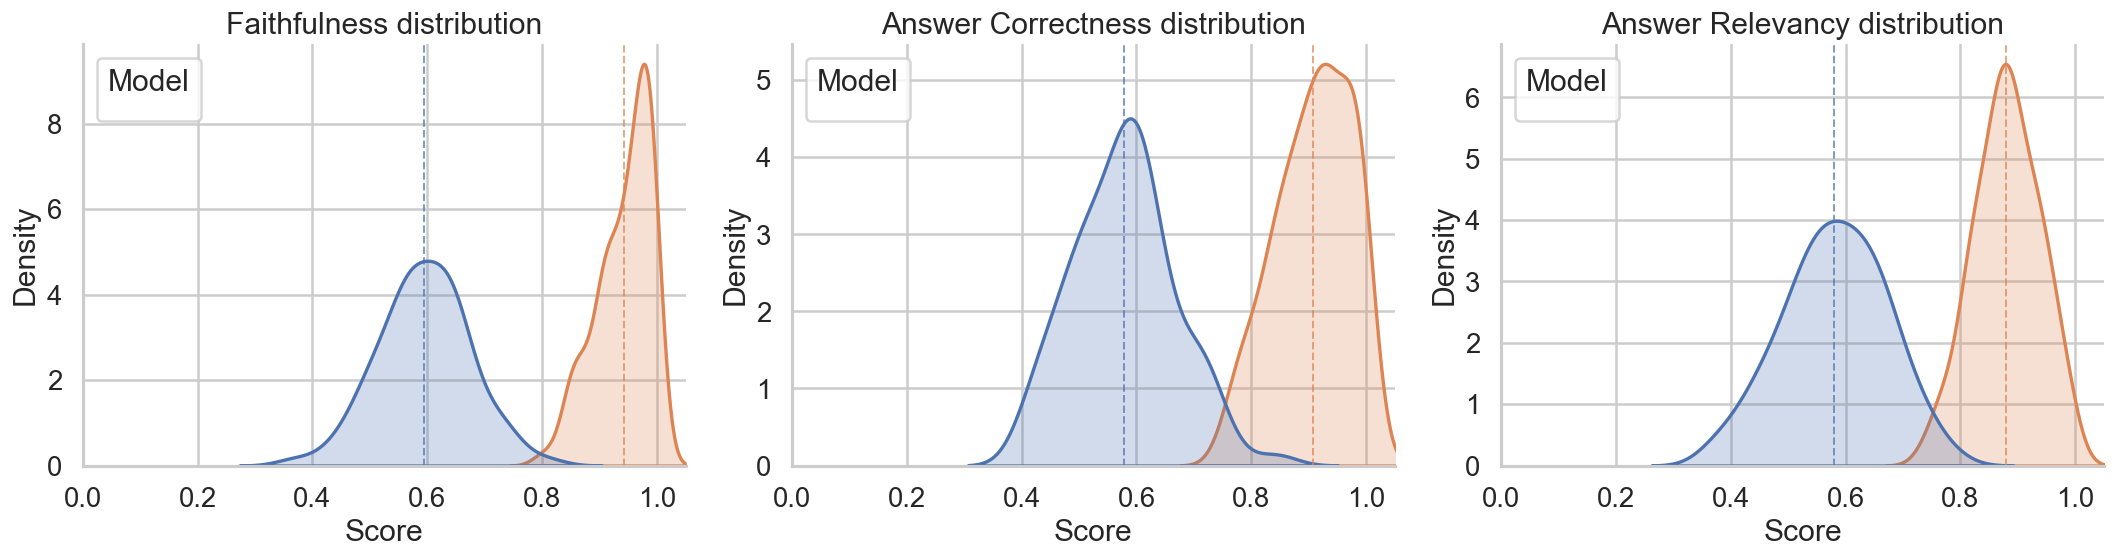

In [40]:

fig, axes = plt.subplots(1, len(PRIMARY_METRICS), figsize=(18, 5), sharex=False)

for ax, metric in zip(axes, PRIMARY_METRICS):
    sns.kdeplot(
        data=df,
        x=metric,
        hue="experiment_label",
        hue_order=MODEL_ORDER,
        palette=MODEL_PALETTE,
        fill=True,
        common_norm=False,
        alpha=0.25,
        linewidth=2,
        ax=ax,
    )
    experiment_means = df.groupby("experiment_label")[metric].mean().reindex(MODEL_ORDER).dropna()
    for label, mean_val in experiment_means.items():
        ax.axvline(mean_val, linestyle="--", linewidth=1.2, alpha=0.7, color=MODEL_PALETTE.get(label))
    ax.set_title(f"{metric.replace('_', ' ').title()} distribution")
    ax.set_xlim(0, 1.05)
    ax.set_xlabel("Score")
    ax.set_ylabel("Density")
    ax.legend(title="Model")

plt.tight_layout()
plt.show()


C:\Users\eoinm\AppData\Local\Temp\ipykernel_11436\3683523911.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(
C:\Users\eoinm\AppData\Local\Temp\ipykernel_11436\3683523911.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(
C:\Users\eoinm\AppData\Local\Temp\ipykernel_11436\3683523911.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(


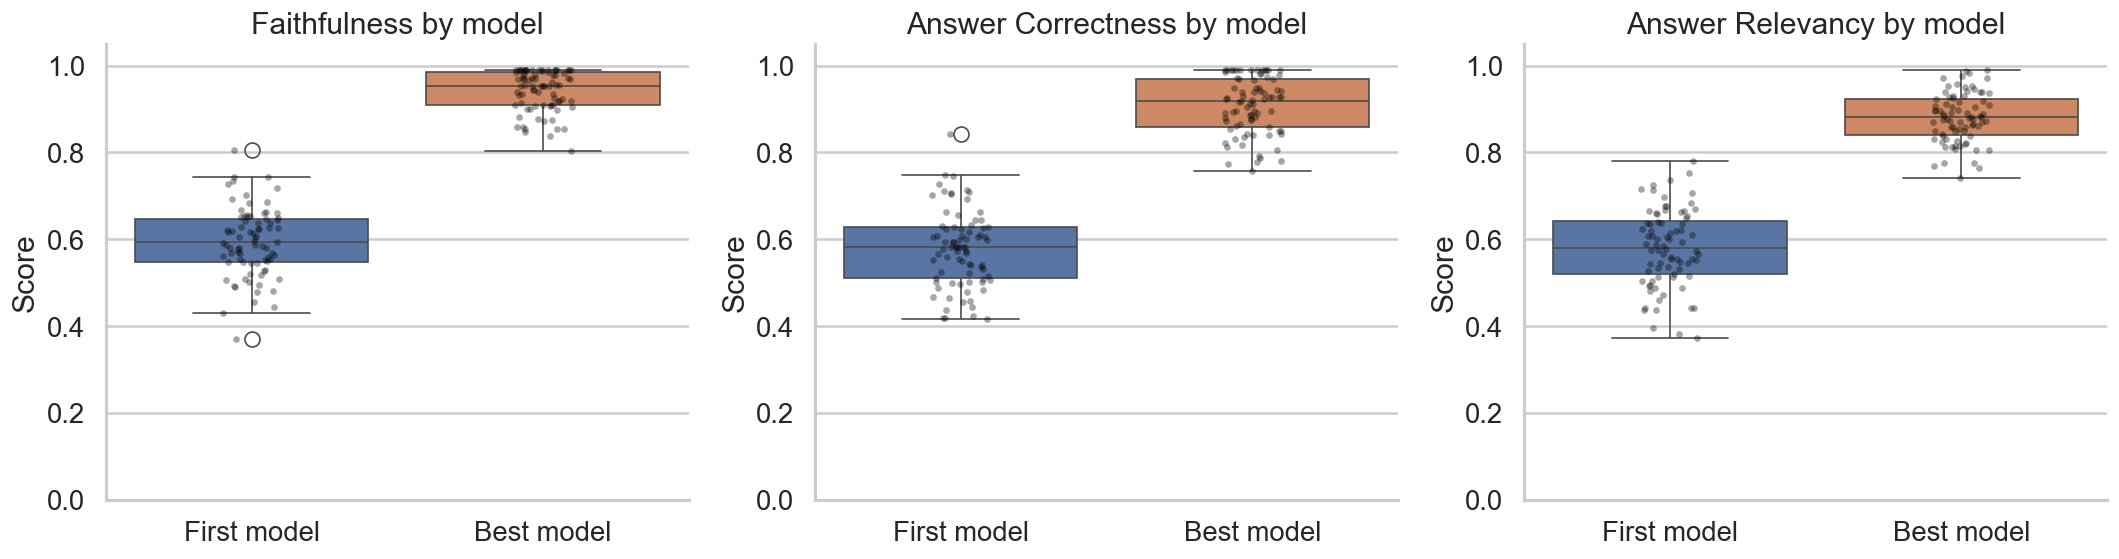

In [41]:

fig, axes = plt.subplots(1, len(PRIMARY_METRICS), figsize=(18, 5), sharey=False)

for ax, metric in zip(axes, PRIMARY_METRICS):
    sns.boxplot(
        data=df,
        x="experiment_label",
        y=metric,
        order=MODEL_ORDER,
        palette=MODEL_PALETTE,
        ax=ax
    )
    sns.stripplot(
        data=df,
        x="experiment_label",
        y=metric,
        order=MODEL_ORDER,
        ax=ax,
        alpha=0.35,
        size=4,
        color="black"
    )
    ax.set_title(f"{metric.replace('_', ' ').title()} by model")
    ax.set_xlabel("")
    ax.set_ylabel("Score")
    ax.set_ylim(0, 1.05)

plt.tight_layout()
plt.show()


## Section-wise analysis

In [42]:

section_summary = (
    df.groupby(["section_order", "section", "experiment_label"], as_index=False)[METRIC_COLS + ["latency_s"]]
      .mean()
      .sort_values(["section_order", "section", "experiment_label"])
)

display(section_summary.head(12).round(3))


,section_order,section,experiment_label,faithfulness,answer_correctness,answer_relevancy,context_precision,context_recall,latency_s
0,1,UCD Connect,Best model,0.940,0.907,0.909,0.867,0.892,1.582
1,1,UCD Connect,First model,0.623,0.624,0.585,0.538,0.470,1.910
2,2,Fees,Best model,0.945,0.903,0.873,0.863,0.885,1.642
3,2,Fees,First model,0.582,0.599,0.608,0.522,0.452,1.938
4,3,Official Documents,Best model,0.931,0.881,0.891,0.858,0.864,1.636
5,3,Official Documents,First model,0.614,0.550,0.563,0.520,0.493,1.974
6,4,Form Stamping,Best model,0.961,0.891,0.820,0.740,0.826,1.696
7,4,Form Stamping,First model,0.546,0.488,0.488,0.570,0.452,1.994
8,5,Registration,Best model,0.966,0.927,0.889,0.872,0.864,1.740
9,5,Registration,First model,0.553,0.555,0.547,0.463,0.457,1.915


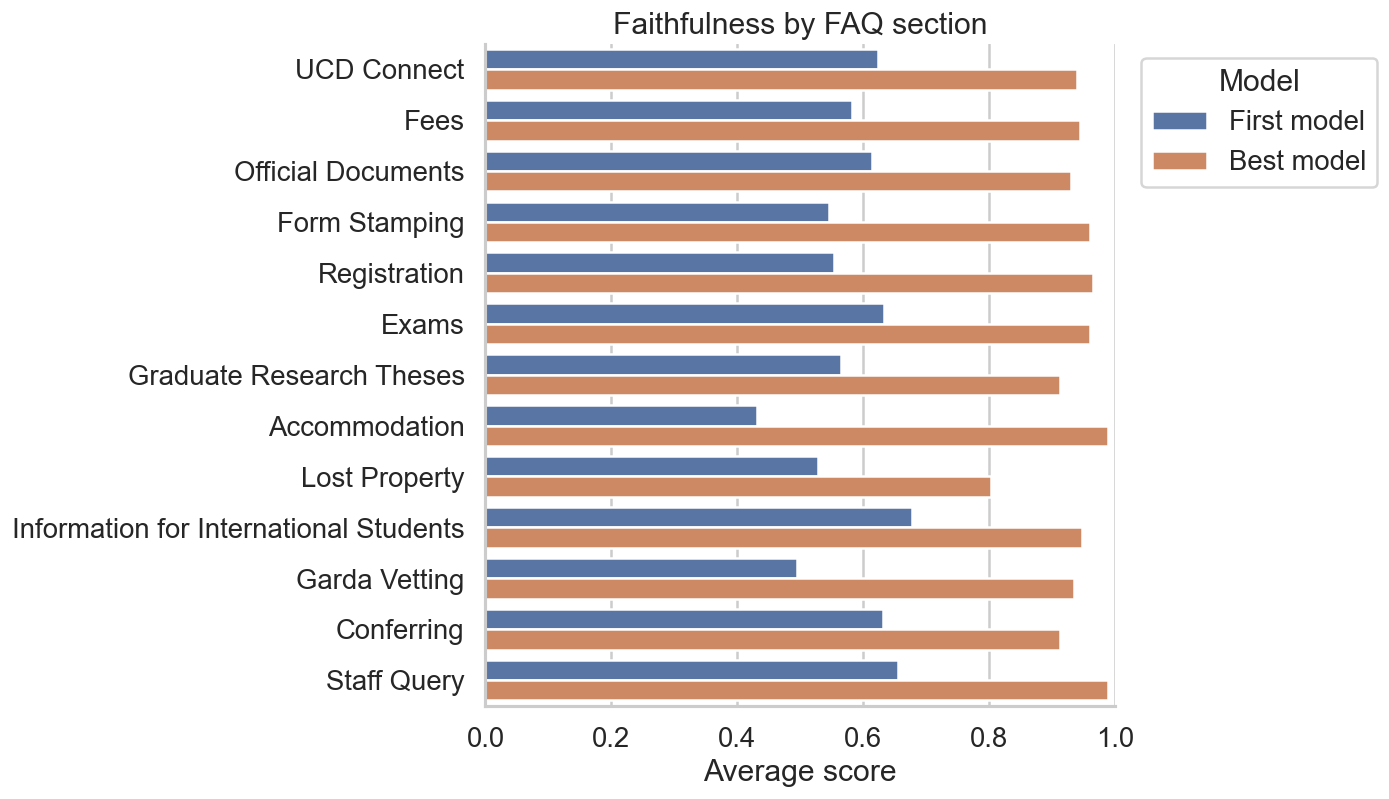

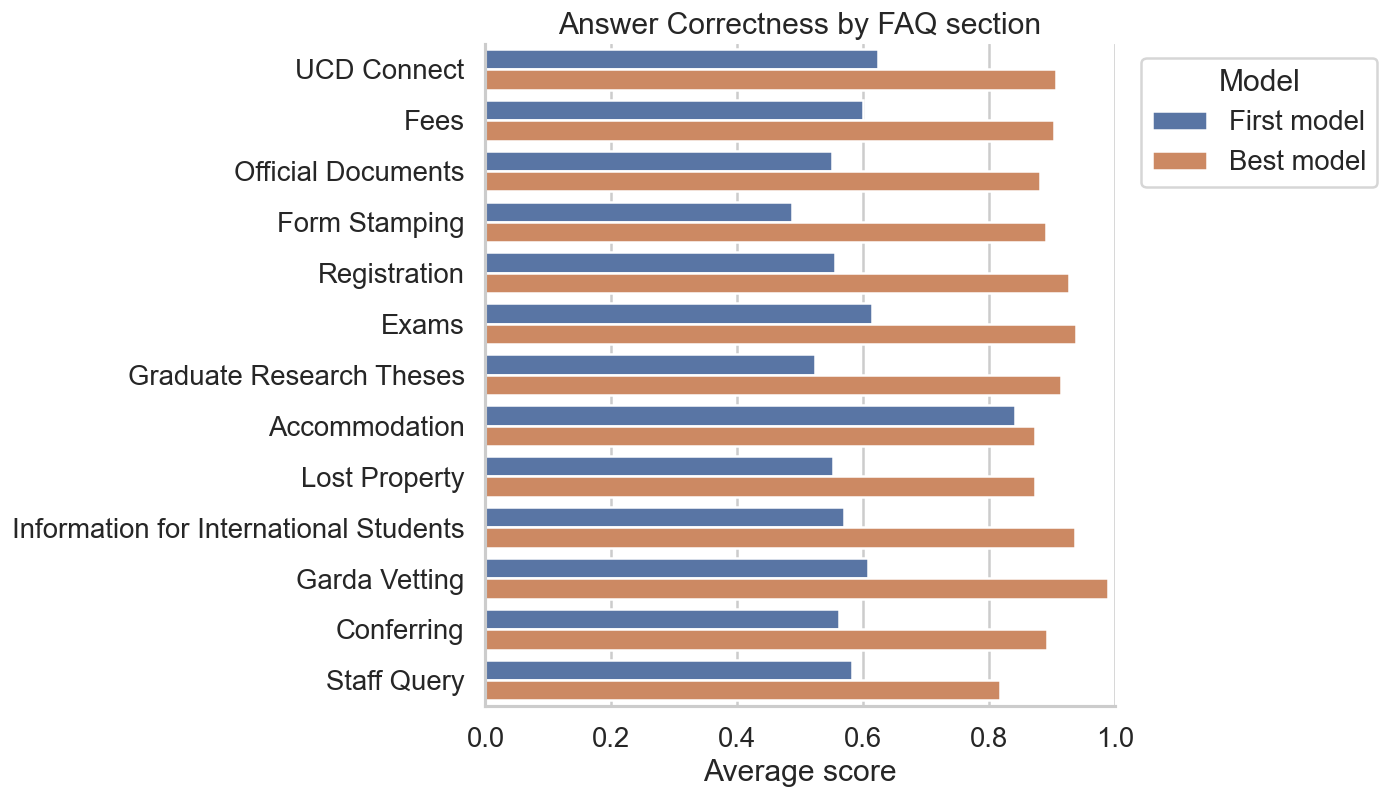

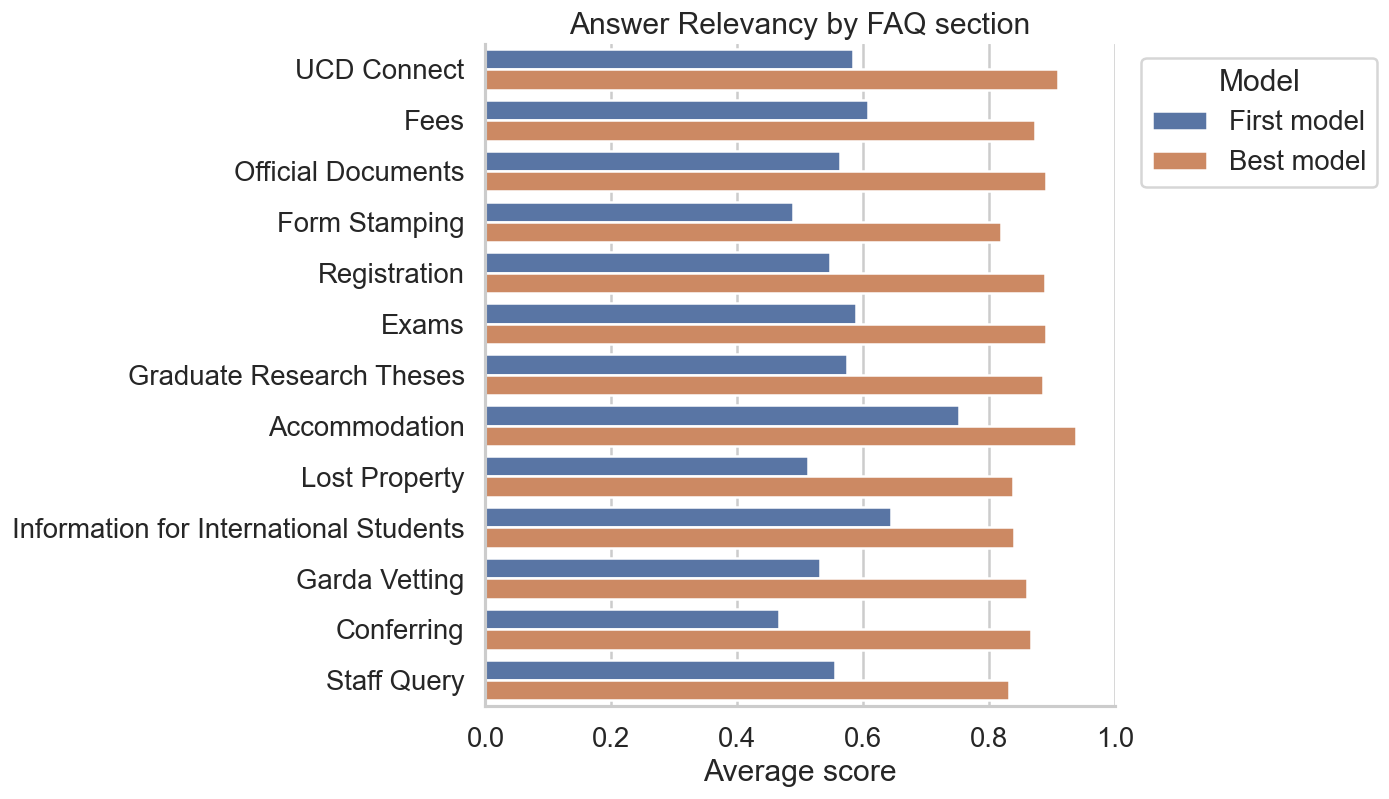

In [56]:

for metric in PRIMARY_METRICS:
    fig, ax = plt.subplots(figsize=(12, 7))
    plot_df = section_summary.sort_values(["section_order", "section"])
    sns.barplot(
        data=plot_df,
        y="section",
        x=metric,
        hue="experiment_label",
        hue_order=MODEL_ORDER,
        palette=MODEL_PALETTE,
        ax=ax
    )
    ax.set_title(f"{metric.replace('_', ' ').title()} by FAQ section")
    ax.set_xlabel("Average score")
    ax.set_ylabel("")
    ax.set_xlim(0, 1)
    ax.legend(title="Model", bbox_to_anchor=(1.02, 1), loc="upper left")
    plt.tight_layout()
    plt.show()


In [57]:
import numpy as np
import matplotlib.pyplot as plt

METRIC_ORDER = ["faithfulness", "answer_correctness", "answer_relevancy"]
METRIC_LABELS = {
    "faithfulness": "Faithfulness",
    "answer_correctness": "Answer Correctness",
    "answer_relevancy": "Answer Relevancy",
}
METRIC_COLOURS = {
    "faithfulness": "#4C72B0",
    "answer_correctness": "#DD8452",
    "answer_relevancy": "#55A868",
}

def plot_section_metric_bars(section_summary, model_label):
    plot_df = (
        section_summary[section_summary["experiment_label"] == model_label]
        .sort_values(["section_order", "section"])
        .copy()
    )

    sections = plot_df["section"].tolist()
    x = np.arange(len(sections))
    width = 0.24
    offsets = [-width, 0, width]

    fig, ax = plt.subplots(figsize=(14, 6))

    for offset, metric in zip(offsets, METRIC_ORDER):
        y = plot_df[metric].to_numpy()
        bars = ax.bar(
            x + offset,
            y,
            width=width,
            color=METRIC_COLOURS[metric],
            alpha=0.9,
            label=METRIC_LABELS[metric]
        )

        for bar, val in zip(bars, y):
            ax.text(
                bar.get_x() + bar.get_width() / 2,
                bar.get_height() + 0.01,
                f"{val:.2f}",
                ha="center",
                va="bottom",
                fontsize=8
            )

    ax.set_title(
        f"{model_label}: core RAGAS metrics by FAQ section",
        fontsize=18,
        fontweight="bold",
        pad=16
    )
    ax.set_xlabel("")
    ax.set_ylabel("Average score")
    ax.set_xticks(x)
    ax.set_xticklabels(sections, rotation=45, ha="right")
    ax.set_ylim(0, 1.05)
    ax.legend(frameon=False, loc="upper right")

    plt.tight_layout()
    plt.show()

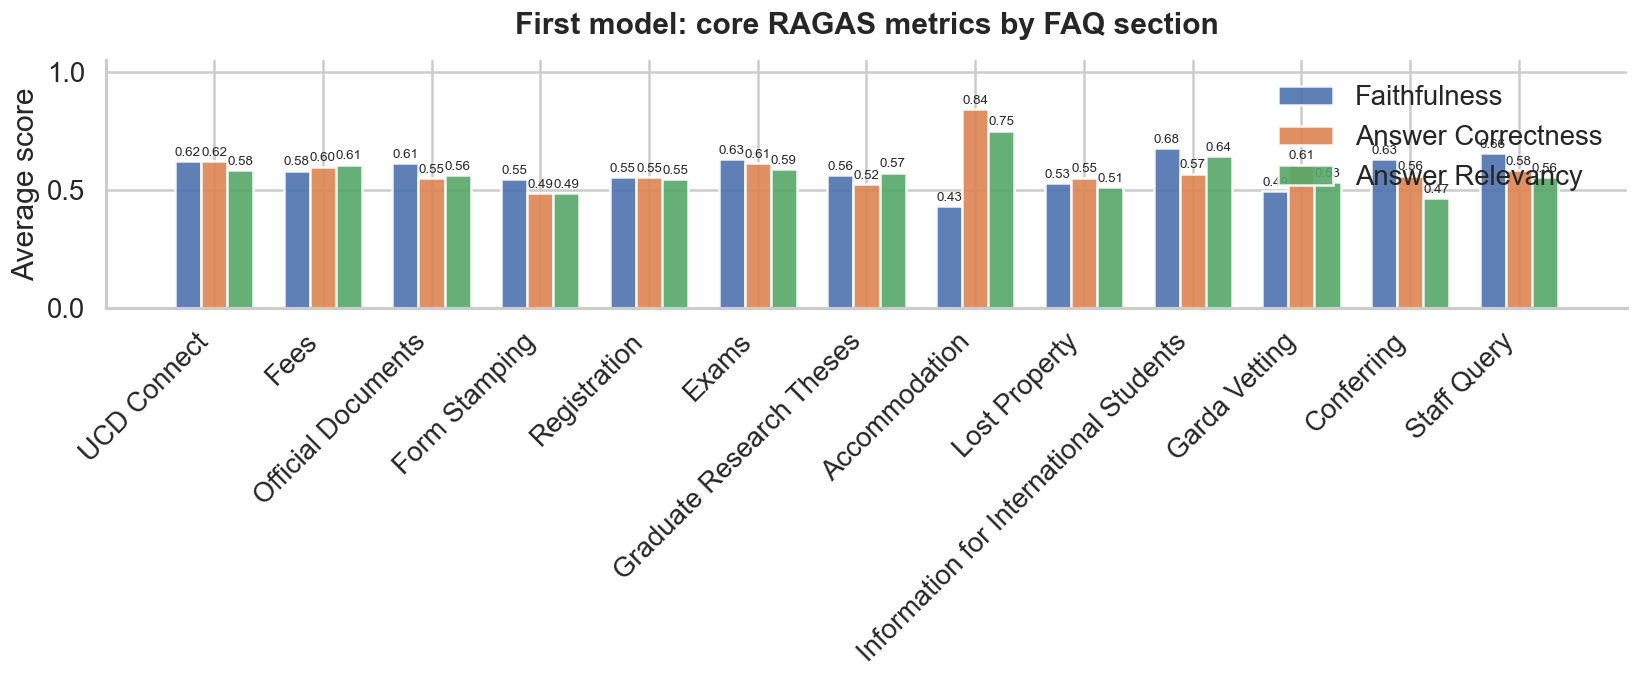

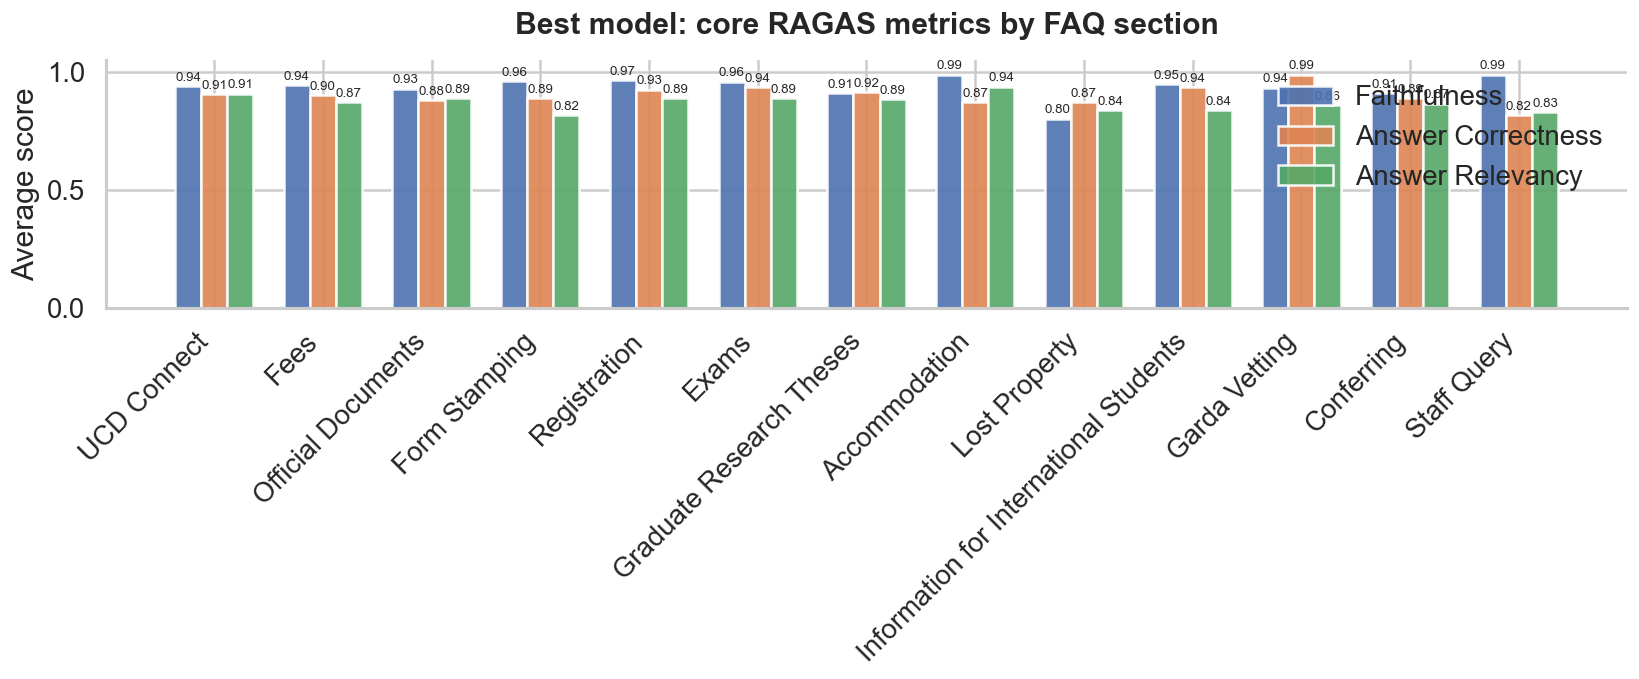

In [58]:
plot_section_metric_bars(section_summary, "First model")
plot_section_metric_bars(section_summary, "Best model")

C:\Users\eoinm\AppData\Local\Temp\ipykernel_11436\2785757819.py:100: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout(rect=[0, 0, 0.86, 0.95])


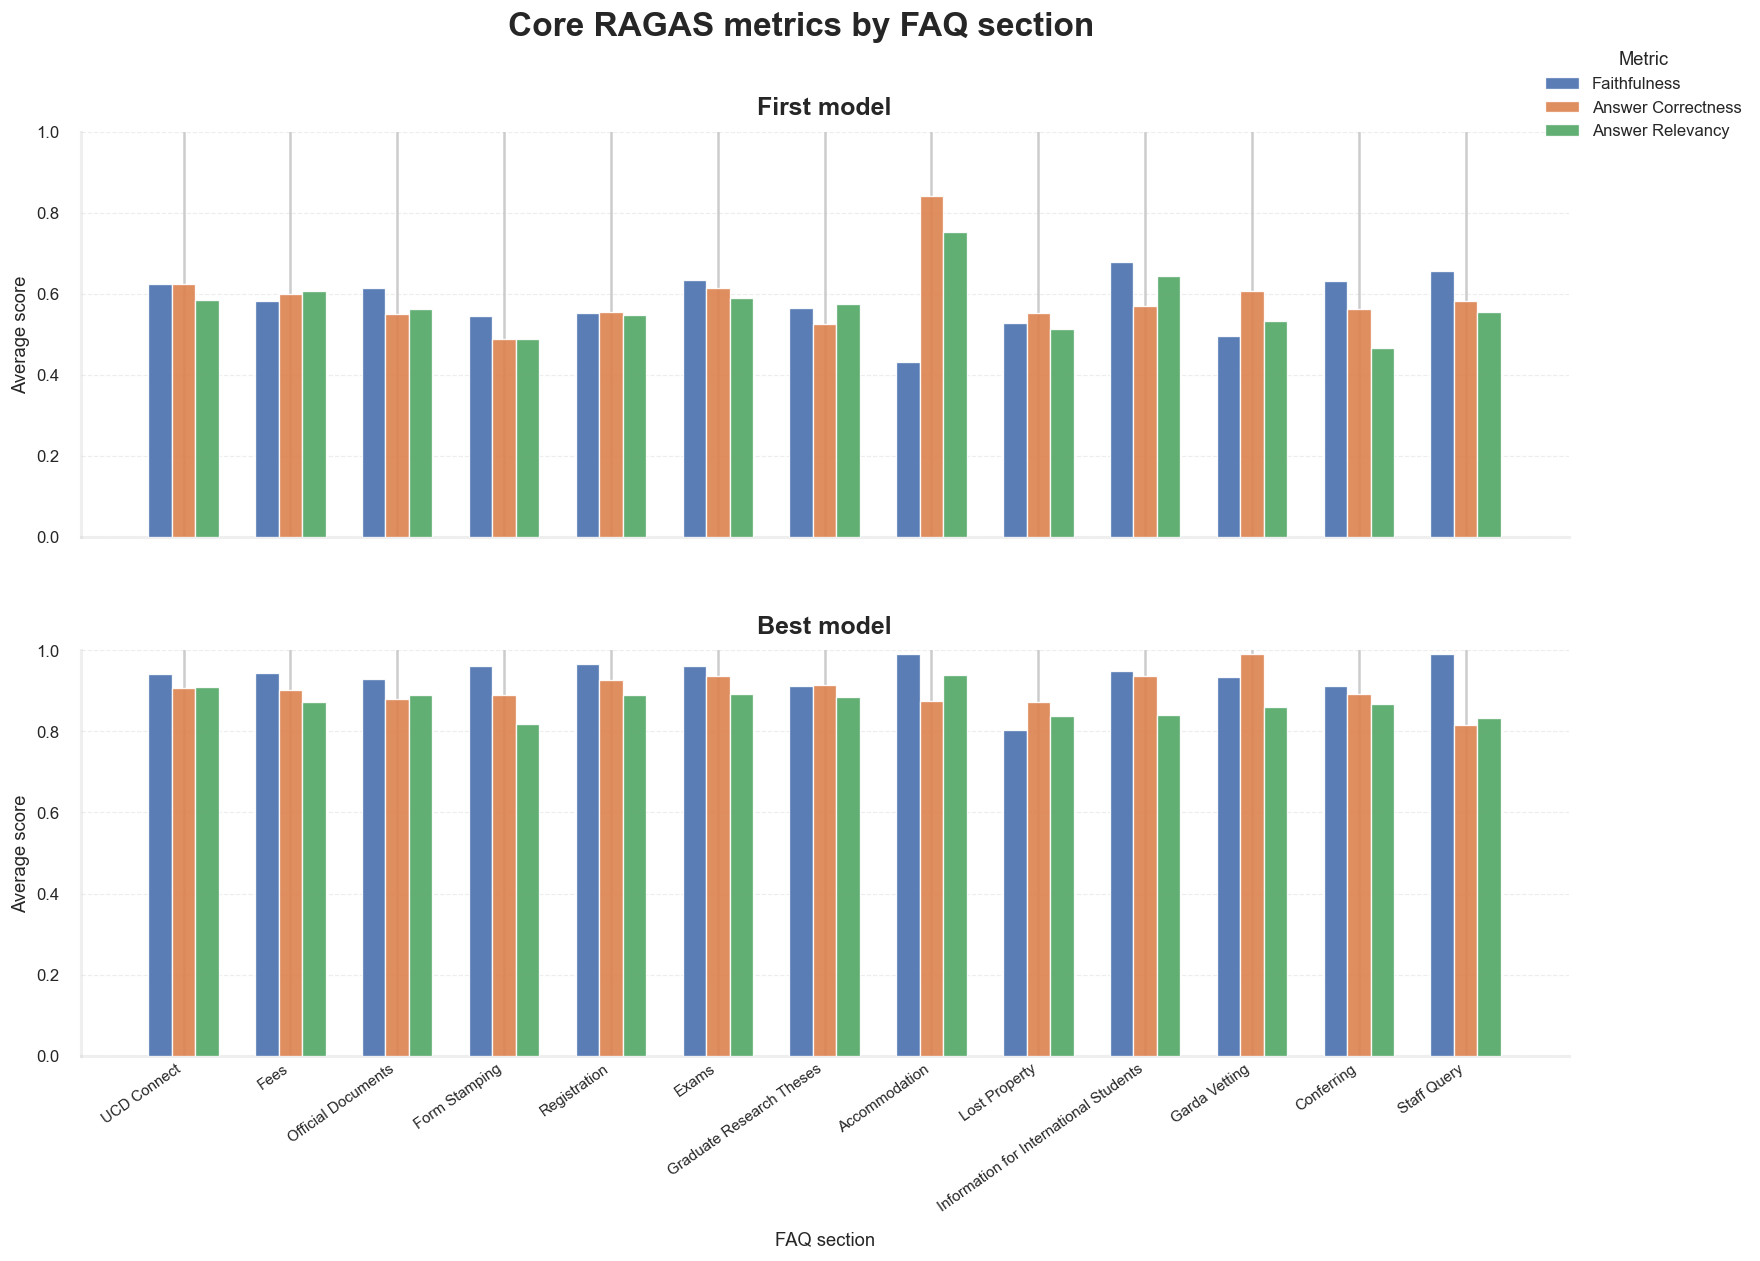

In [ ]:
import numpy as np
import matplotlib.pyplot as plt

METRIC_ORDER = ["faithfulness", "answer_correctness", "answer_relevancy"]
METRIC_LABELS = {
    "faithfulness": "Faithfulness",
    "answer_correctness": "Answer Correctness",
    "answer_relevancy": "Answer Relevancy",
}
METRIC_COLOURS = {
    "faithfulness": "#4C72B0",
    "answer_correctness": "#DD8452",
    "answer_relevancy": "#55A868",
}

fig, axes = plt.subplots(
    2, 1,
    figsize=(16, 10),
    sharex=True,
    gridspec_kw={"hspace": 0.28}
)

for ax, model_label in zip(axes, MODEL_ORDER):
    plot_df = (
        section_summary[section_summary["experiment_label"] == model_label]
        .sort_values(["section_order", "section"])
        .copy()
    )

    sections = plot_df["section"].tolist()
    x = np.arange(len(sections))
    width = 0.22
    offsets = [-width, 0, width]

    for offset, metric in zip(offsets, METRIC_ORDER):
        y = plot_df[metric].to_numpy()
        ax.bar(
            x + offset,
            y,
            width=width,
            color=METRIC_COLOURS[metric],
            alpha=0.92,
            edgecolor="white",
            linewidth=0.8,
            label=METRIC_LABELS[metric],
            zorder=3
        )

    ax.set_title(model_label, fontsize=15, fontweight="bold", pad=10)
    ax.set_ylabel("Average score", fontsize=11)
    ax.set_ylim(0, 1.0)

    # Light horizontal gridlines
    ax.grid(axis="y", linestyle="--", linewidth=0.7, alpha=0.35, zorder=0)

    # Reduce clutter
    ax.spines["top"].set_visible(False)
    ax.spines["right"].set_visible(False)
    ax.spines["left"].set_alpha(0.3)
    ax.spines["bottom"].set_alpha(0.3)

    # Tidy tick labels
    ax.tick_params(axis="y", labelsize=10)
    ax.tick_params(axis="x", length=0)

    if ax.legend_:
        ax.legend_.remove()

# Shared legend outside top-right
handles, labels = axes[0].get_legend_handles_labels()
fig.legend(
    handles,
    labels,
    title="Metric",
    title_fontsize=11,
    fontsize=10,
    frameon=False,
    loc="upper left",
    bbox_to_anchor=(0.80, 0.96)  # 👈 moved left
)

# X-axis labels
axes[-1].set_xticks(np.arange(len(sections)))
axes[-1].set_xticklabels(
    sections,
    rotation=35,
    ha="right",
    fontsize=9
)
axes[-1].set_xlabel("FAQ section", fontsize=11, labelpad=10)

fig.suptitle(
    "Core RAGAS metrics by FAQ section",
    fontsize=20,
    fontweight="bold",
    y=0.98
)

# Leave room for legend on the right
plt.tight_layout(rect=[0, 0, 0.86, 0.95])
plt.show()

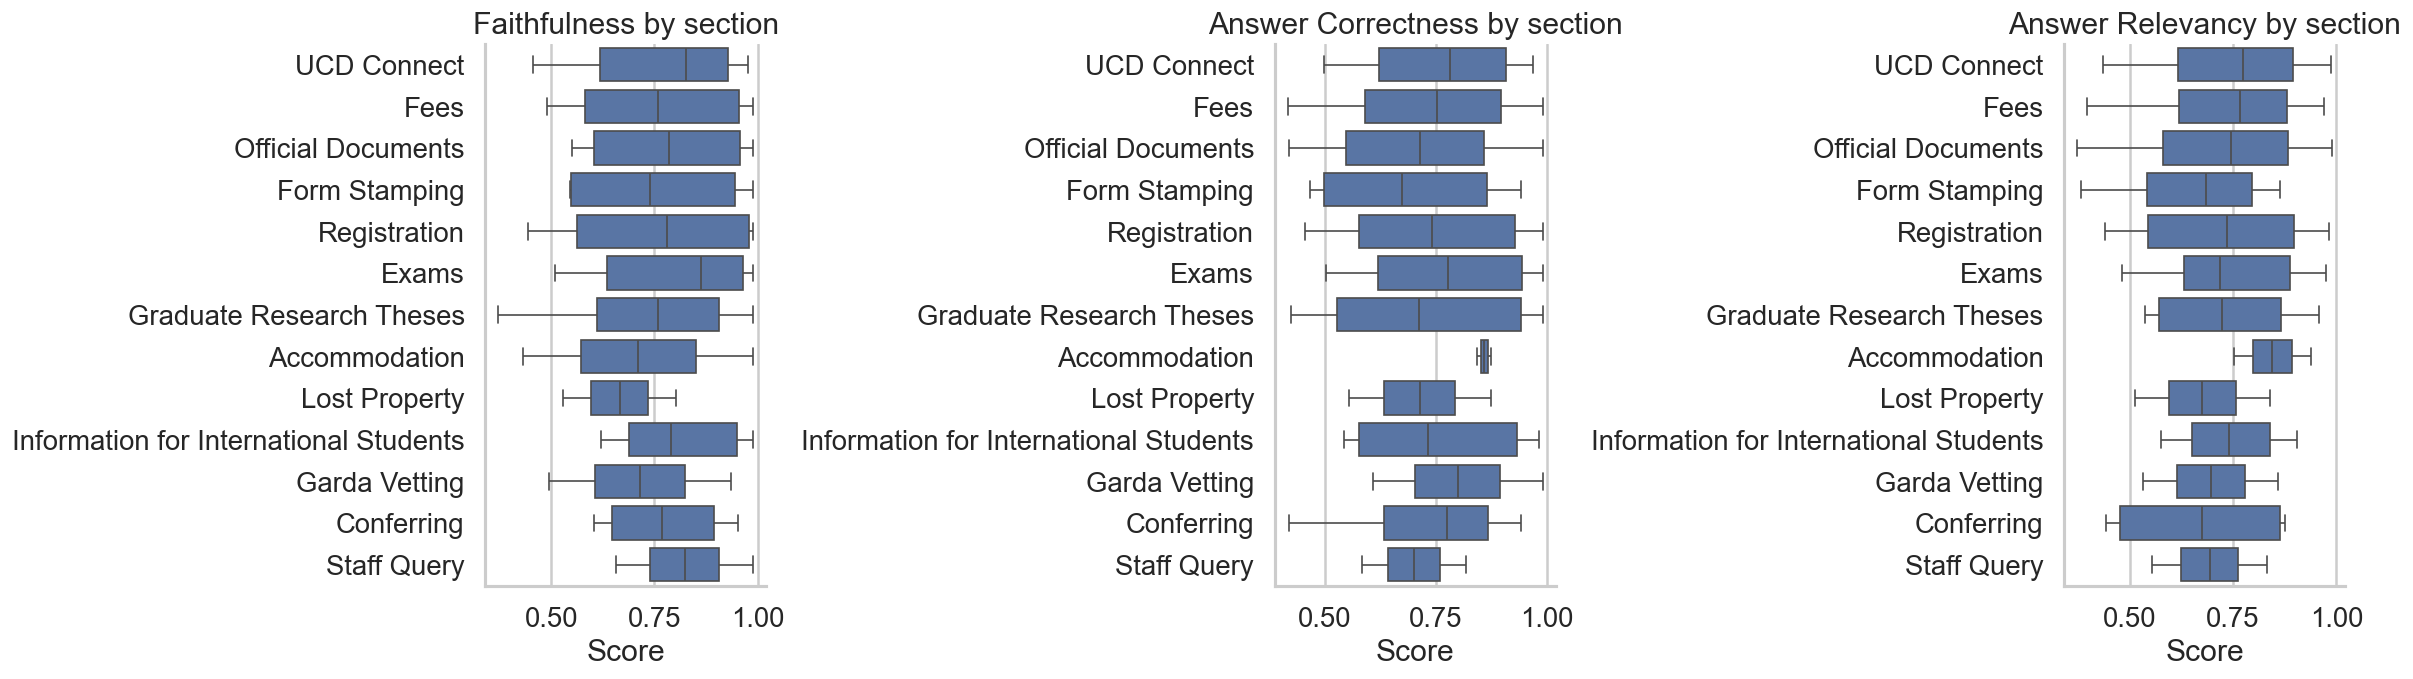

In [44]:
fig, axes = plt.subplots(1, len(PRIMARY_METRICS), figsize=(20, 6), sharex=False)

section_order = (
    faq_df[["section_order", "section"]]
    .drop_duplicates()
    .sort_values("section_order")["section"]
    .tolist()
)

for ax, metric in zip(axes, PRIMARY_METRICS):
    sns.boxplot(
        data=df,
        x=metric,
        y="section",
        order=section_order,
        ax=ax
    )
    ax.set_title(f"{metric.replace('_', ' ').title()} by section")
    ax.set_xlabel("Score")
    ax.set_ylabel("")

plt.tight_layout()
plt.show()

## Retrieval quality vs answer quality

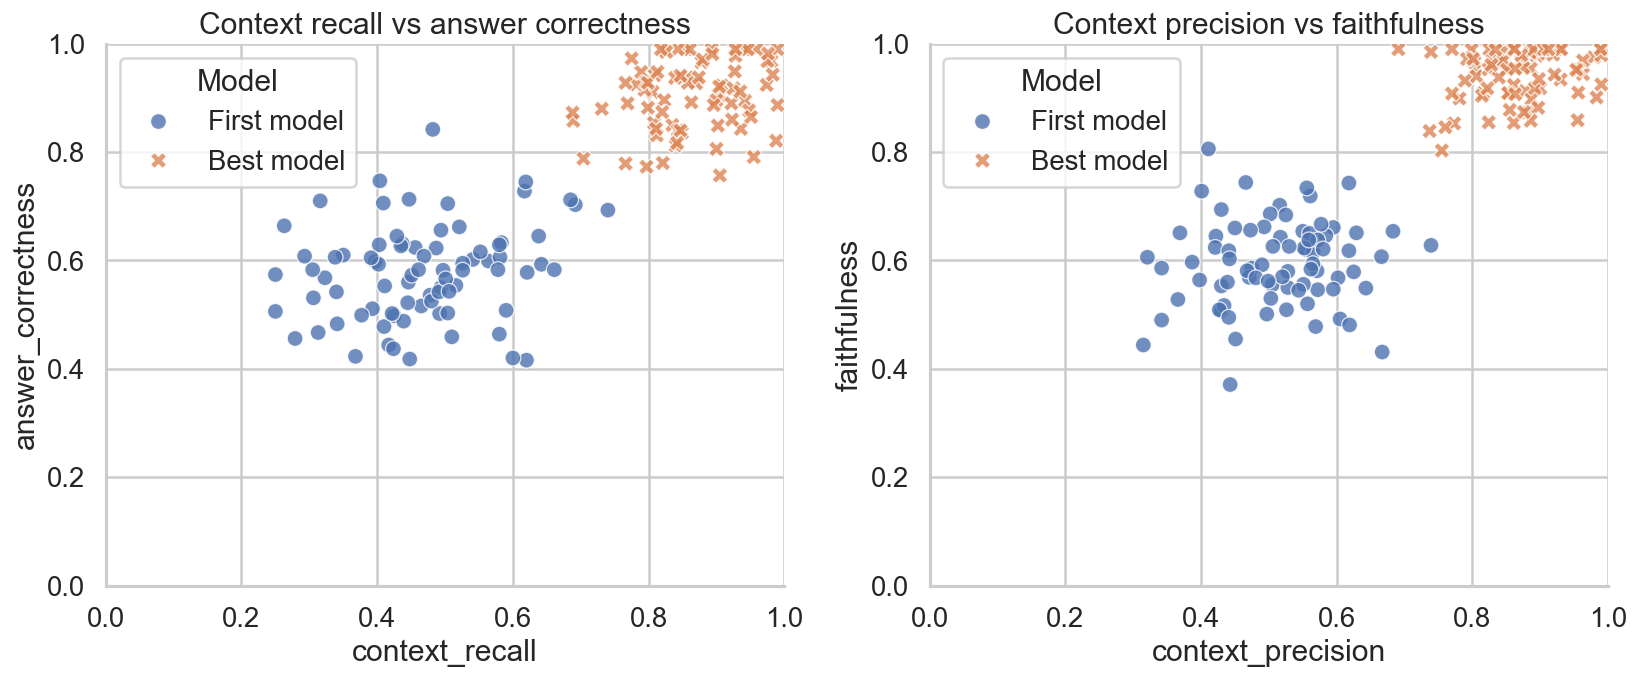

In [45]:

fig, axes = plt.subplots(1, 2, figsize=(14, 6), sharex=False, sharey=False)

sns.scatterplot(
    data=df,
    x="context_recall",
    y="answer_correctness",
    hue="experiment_label",
    style="experiment_label",
    hue_order=MODEL_ORDER,
    palette=MODEL_PALETTE,
    s=90,
    alpha=0.8,
    ax=axes[0]
)
axes[0].set_title("Context recall vs answer correctness")
axes[0].set_xlim(0, 1)
axes[0].set_ylim(0, 1)
axes[0].legend(title="Model")

sns.scatterplot(
    data=df,
    x="context_precision",
    y="faithfulness",
    hue="experiment_label",
    style="experiment_label",
    hue_order=MODEL_ORDER,
    palette=MODEL_PALETTE,
    s=90,
    alpha=0.8,
    ax=axes[1]
)
axes[1].set_title("Context precision vs faithfulness")
axes[1].set_xlim(0, 1)
axes[1].set_ylim(0, 1)
axes[1].legend(title="Model")

plt.tight_layout()
plt.show()


## Correlation analysis

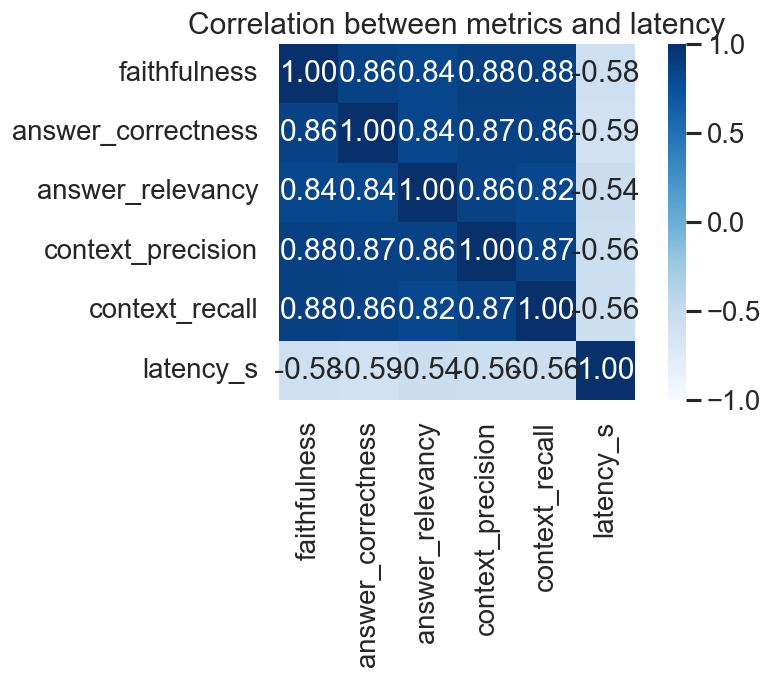

,faithfulness,answer_correctness,answer_relevancy,context_precision,context_recall,latency_s
faithfulness,1.00,0.86,0.84,0.88,0.88,-0.58
answer_correctness,0.86,1.00,0.84,0.87,0.86,-0.59
answer_relevancy,0.84,0.84,1.00,0.86,0.82,-0.54
context_precision,0.88,0.87,0.86,1.00,0.87,-0.56
context_recall,0.88,0.86,0.82,0.87,1.00,-0.56
latency_s,-0.58,-0.59,-0.54,-0.56,-0.56,1.00


In [46]:
corr = df[METRIC_COLS + ["latency_s"]].corr()

fig, ax = plt.subplots(figsize=(8, 6))
sns.heatmap(
    corr,
    annot=True,
    fmt=".2f",
    cmap="Blues",
    vmin=-1,
    vmax=1,
    square=True,
    ax=ax
)
ax.set_title("Correlation between metrics and latency")
plt.tight_layout()
plt.show()

corr.round(2)

## Latency vs quality

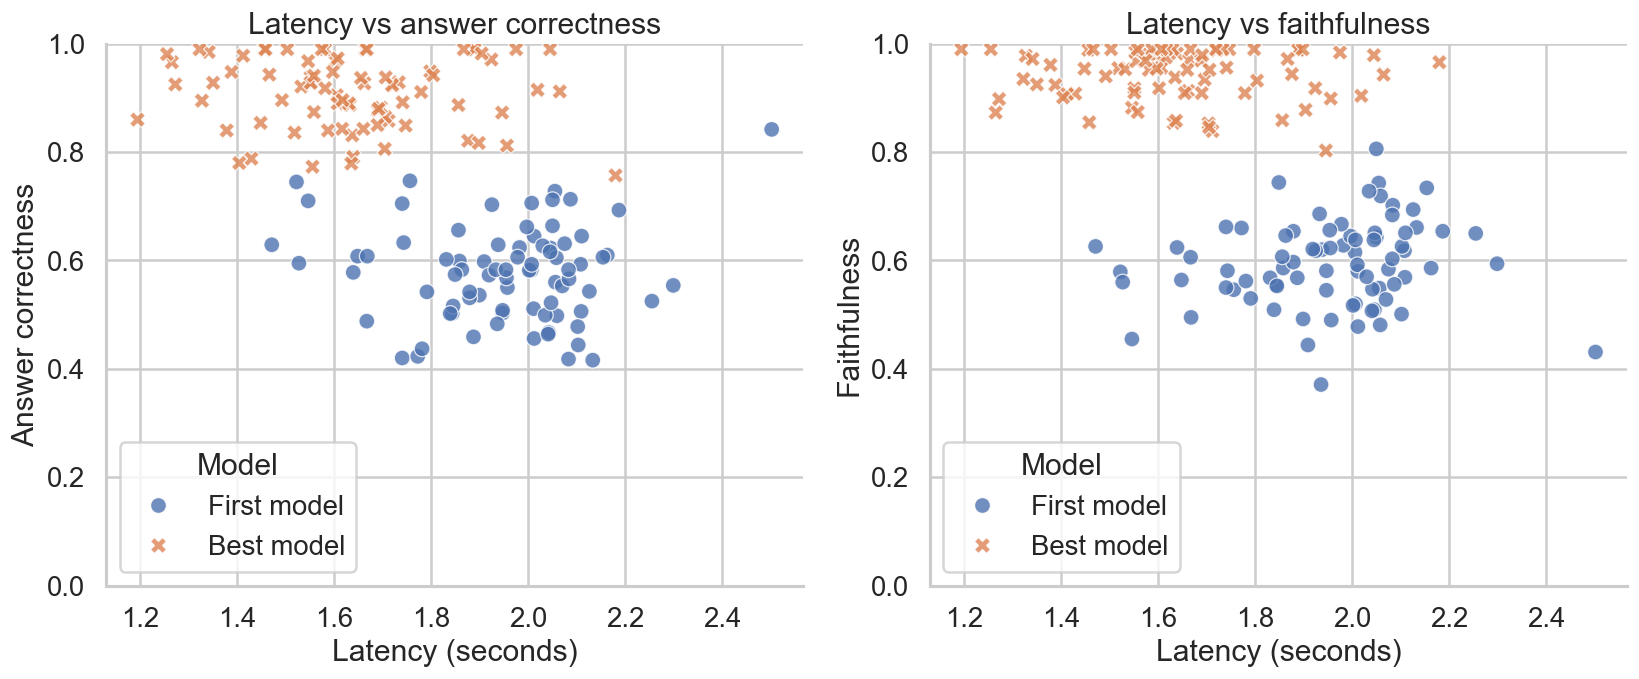

In [47]:

fig, axes = plt.subplots(1, 2, figsize=(14, 6))

sns.scatterplot(
    data=df,
    x="latency_s",
    y="answer_correctness",
    hue="experiment_label",
    style="experiment_label",
    hue_order=MODEL_ORDER,
    palette=MODEL_PALETTE,
    s=90,
    alpha=0.8,
    ax=axes[0]
)
axes[0].set_title("Latency vs answer correctness")
axes[0].set_xlabel("Latency (seconds)")
axes[0].set_ylabel("Answer correctness")
axes[0].set_ylim(0, 1)
axes[0].legend(title="Model")

sns.scatterplot(
    data=df,
    x="latency_s",
    y="faithfulness",
    hue="experiment_label",
    style="experiment_label",
    hue_order=MODEL_ORDER,
    palette=MODEL_PALETTE,
    s=90,
    alpha=0.8,
    ax=axes[1]
)
axes[1].set_title("Latency vs faithfulness")
axes[1].set_xlabel("Latency (seconds)")
axes[1].set_ylabel("Faithfulness")
axes[1].set_ylim(0, 1)
axes[1].legend(title="Model")

plt.tight_layout()
plt.show()


## Question-level comparison between experiments

In [48]:

question_compare = (
    df.pivot_table(
        index=["section", "question"],
        columns="experiment_label",
        values=METRIC_COLS + ["latency_s"],
        aggfunc="mean"
    )
    .sort_index()
)

display(question_compare.head(10).round(3))


answer_correctness  \
experiment_label                                                                                   Best model   
section       question                                                                                          
Accommodation Where can I find information on both on-campus and off-campus accommodation?              0.874   
Conferring    I am due to confer in September or December, what do I need to know?                      0.843   
              Where can I find further information about conferring?                                    0.941   
Exams         Are final results for all programmes available online?                                    0.948   
              Can I check a hold on my record?                                                          0.990   
              How do I appeal a grade?                                                                  0.896   
              How do I calculate my Degree Award GPA?                                                   0.971   
              How do I view my results?                                                                 0.928   
              What is the difference between a repeat and a resit?                                      0.840   
              When are the end of term exams and when are results released?                             0.985   

                                                                                                        \
experiment_label                                                                           First model   
section       question                                                                                   
Accommodation Where can I find information on both on-campus and off-campus accommodation?       0.842   
Conferring    I am due to confer in September or December, what do I need to know?               0.705   
              Where can I find further information about conferring?                             0.418   
Exams         Are final results for all programmes available online?                             0.502   
              Can I check a hold on my record?                                                   0.627   
              How do I appeal a grade?                                                           0.593   
              How do I calculate my Degree Award GPA?                                            0.712   
              How do I view my results?                                                          0.629   
              What is the difference between a repeat and a resit?                               0.693   
              When are the end of term exams and when are results released?                      0.582   

                                                                                           answer_relevancy  \
experiment_label                                                                                 Best model   
section       question                                                                                        
Accommodation Where can I find information on both on-campus and off-campus accommodation?            0.939   
Conferring    I am due to confer in September or December, what do I need to know?                    0.875   
              Where can I find further information about conferring?                                  0.859   
Exams         Are final results for all programmes available online?                                  0.876   
              Can I check a hold on my record?                                                        0.849   
              How do I appeal a grade?                                                                0.922   
              How do I calculate my Degree Award GPA?                                                 0.927   
              How do I view my results?                                                               0.971   
              What is

In [49]:

experiment_order = [label for label in MODEL_ORDER if label in df["experiment_label"].unique()]

if len(experiment_order) >= 2:
    exp_a, exp_b = experiment_order[:2]

    compare_cols = ["faithfulness", "answer_correctness", "answer_relevancy"]
    wide = (
        df.pivot_table(
            index=["section", "question"],
            columns="experiment_label",
            values=compare_cols,
            aggfunc="mean"
        )
        .sort_index()
    )

    delta_df = pd.DataFrame(index=wide.index)
    for metric in compare_cols:
        delta_df[f"{metric}_delta_{exp_b}_minus_{exp_a}"] = wide[(metric, exp_b)] - wide[(metric, exp_a)]

    delta_df = delta_df.reset_index().sort_values(
        f"answer_correctness_delta_{exp_b}_minus_{exp_a}",
        ascending=False
    )

    display(Markdown(f"### Largest answer correctness gains: {exp_b} vs {exp_a}"))
    display(delta_df.head(10).round(3))

    display(Markdown(f"### Largest answer correctness drops: {exp_b} vs {exp_a}"))
    display(delta_df.tail(10).round(3))
else:
    print("At least two experiments are required for delta analysis.")


### Largest answer correctness gains: Best model vs First model

,section,question,faithfulness_delta_Best model_minus_First model,answer_correctness_delta_Best model_minus_First model,answer_relevancy_delta_Best model_minus_First model
35,Graduate Research Theses,Can I submit my thesis electronically?,0.195,0.567,0.241
40,Graduate Research Theses,"If I submitted my thesis electronically, do I still need to submit a hardbound copy?",0.345,0.541,0.388
65,Registration,How do I withdraw from my programme?,0.472,0.526,0.269
2,Conferring,Where can I find further information about conferring?,0.271,0.523,0.370
26,Fees,I think I should be on the EU Fees rate - what should I do?,0.243,0.499,0.338
42,Graduate Research Theses,Where can I find guidelines/regulations about thesis formatting?,0.619,0.498,0.212
51,Official Documents,Can UCD email/scan my official documents to me and/or a third party?,0.403,0.487,0.292
66,Registration,I have a questions about UCD Micro-credentials,0.338,0.468,0.327
70,Registration,Where can I find a syllabus/module descriptors of my course?,0.474,0.462,0.429
67,Registration,What are extenuating circumstances & how do I apply?,0.489,0.446,0.491


### Largest answer correctness drops: Best model vs First model

,section,question,faithfulness_delta_Best model_minus_First model,answer_correctness_delta_Best model_minus_First model,answer_relevancy_delta_Best model_minus_First model
20,Fees,How do I request a Canadian Tax Form?,0.342,0.212,0.332
12,Fees,Can I make a payment over the phone?,0.374,0.209,0.270
75,UCD Connect,"How do I log in to UCD IT Systems including SISWeb, Brightspace or UCD Email?",0.335,0.207,0.435
77,UCD Connect,What is SISWeb? What is Brightspace?,0.166,0.183,0.284
68,Registration,What is a Leave of Absence and how do I apply?,0.494,0.181,0.367
30,Fees,Who is eligible for EU Fees?,0.394,0.149,0.383
8,Exams,What is the difference between a repeat and a resit?,0.307,0.147,0.202
1,Conferring,"I am due to confer in September or December, what do I need to know?",0.290,0.138,0.432
62,Official Documents,Why do my results say pending?,0.361,0.117,0.321
0,Accommodation,Where can I find information on both on-campus and off-campus accommodation?,0.559,0.032,0.187


## Worst-performing questions

In [50]:

worst_questions = (
    df.sort_values(["answer_correctness", "faithfulness", "answer_relevancy"], ascending=[True, True, True])
      [[
          "experiment_label",
          "section",
          "question",
          "faithfulness",
          "answer_correctness",
          "answer_relevancy",
          "context_precision",
          "context_recall",
          "latency_s",
      ]]
      .head(15)
)

display(worst_questions.round(3))


,experiment_label,section,question,faithfulness,answer_correctness,answer_relevancy,context_precision,context_recall,latency_s
11,First model,Fees,I think I should be on the EU Fees rate - what should I do?,0.661,0.416,0.559,0.595,0.620,2.133
77,First model,Conferring,Where can I find further information about conferring?,0.603,0.418,0.489,0.442,0.448,2.083
33,First model,Official Documents,Where can I get a Certificate of Attendance?,0.550,0.420,0.556,0.528,0.600,1.740
61,First model,Graduate Research Theses,Can I submit my thesis electronically?,0.660,0.423,0.567,0.450,0.368,1.772
65,First model,Graduate Research Theses,"If I submitted my thesis electronically, do I still need to submit a hardbound copy?",0.562,0.437,0.566,0.499,0.424,1.781
64,First model,Graduate Research Theses,How many copies of my thesis do I need to submit?,0.626,0.444,0.537,0.506,0.417,2.103
46,First model,Registration,Where can I find a syllabus/module descriptors of my course?,0.478,0.456,0.521,0.569,0.279,2.012
45,First model,Registration,What is a substitute module?,0.568,0.459,0.471,0.481,0.510,1.887
48,First model,Registration,How do I withdraw from my programme?,0.507,0.464,0.545,0.430,0.580,2.041
41,First model,Form Stamping,How do I get a form stamped?,0.547,0.467,0.383,0.595,0.313,2.042


,section,questions,low_correctness_cases,avg_correctness,low_correctness_rate
4,Form Stamping,2,2,0.689,1.0
11,Staff Query,1,1,0.700,1.0
8,Lost Property,1,1,0.713,1.0
9,Official Documents,14,14,0.716,1.0
6,Graduate Research Theses,8,8,0.720,1.0
1,Conferring,2,2,0.727,1.0
10,Registration,10,10,0.741,1.0
3,Fees,21,21,0.751,1.0
7,Information for International Students,5,5,0.753,1.0
12,UCD Connect,6,6,0.766,1.0


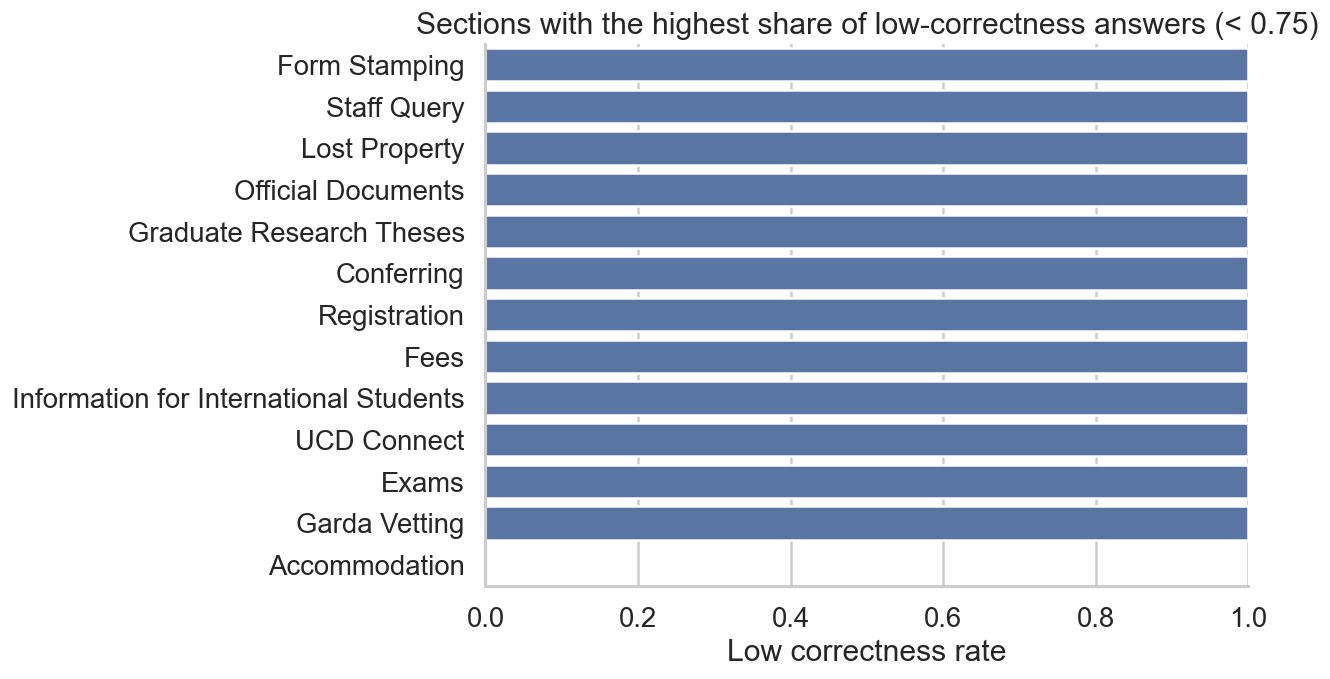

In [51]:
low_score_threshold = 0.75

error_by_section = (
    df.assign(low_correctness=df["answer_correctness"] < low_score_threshold)
      .groupby("section", as_index=False)
      .agg(
          questions=("question", "nunique"),
          low_correctness_cases=("low_correctness", "sum"),
          avg_correctness=("answer_correctness", "mean")
      )
)

error_by_section["low_correctness_rate"] = (
    error_by_section["low_correctness_cases"] / error_by_section["questions"]
)

error_by_section = error_by_section.sort_values(
    ["low_correctness_rate", "avg_correctness"],
    ascending=[False, True]
)

display(error_by_section.round(3))

fig, ax = plt.subplots(figsize=(11, 6))
sns.barplot(data=error_by_section, y="section", x="low_correctness_rate", ax=ax)
ax.set_title(f"Sections with the highest share of low-correctness answers (< {low_score_threshold:.2f})")
ax.set_xlabel("Low correctness rate")
ax.set_ylabel("")
ax.set_xlim(0, 1)
plt.tight_layout()
plt.show()

## Optional: radar chart summary

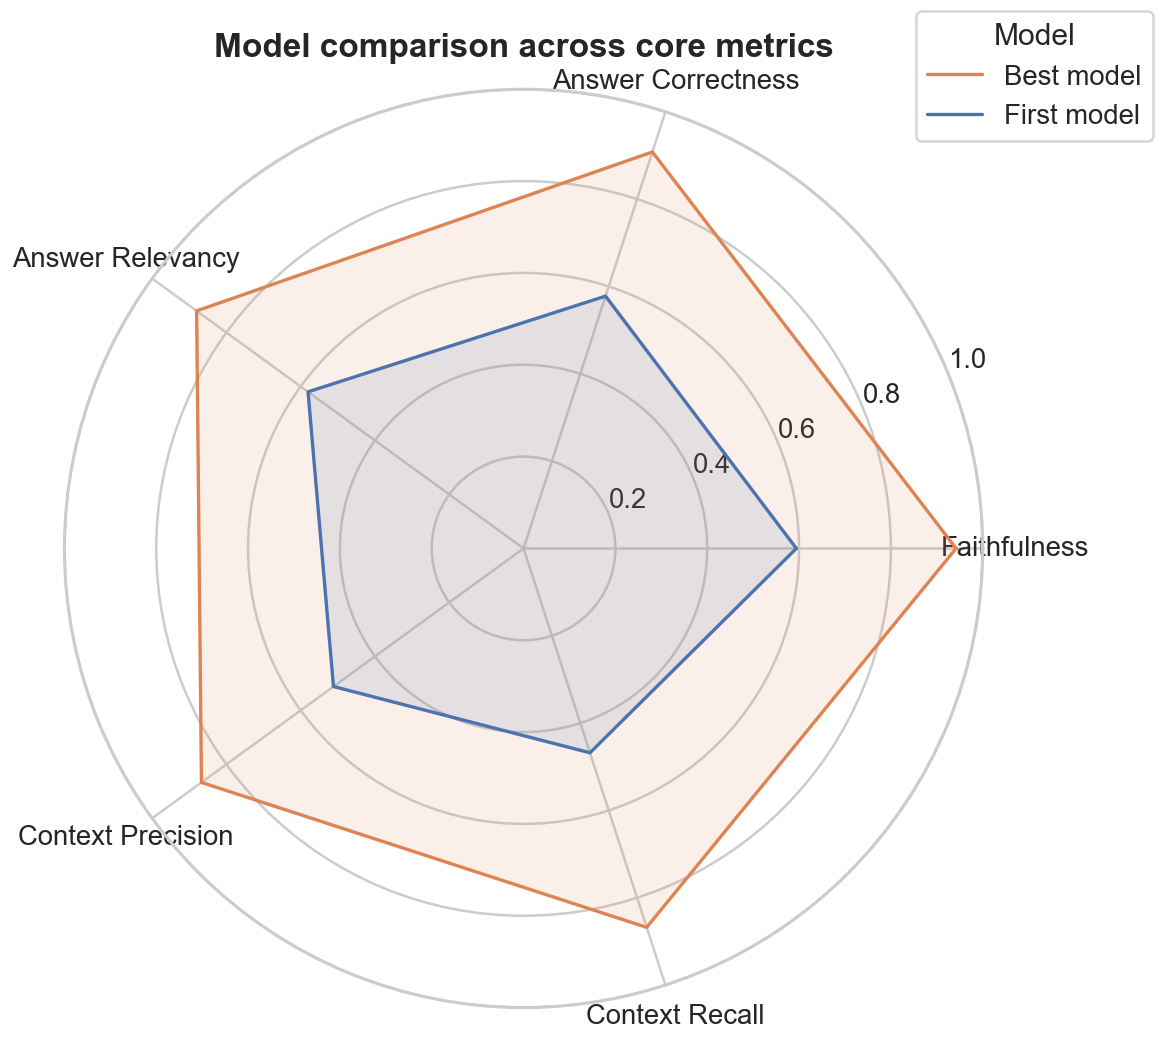

In [52]:

# Radar chart for a compact slide-friendly comparison
radar_metrics = PRIMARY_METRICS + ["context_precision", "context_recall"]
radar_df = summary_df[["experiment_label"] + radar_metrics].copy()

labels = radar_metrics
angles = np.linspace(0, 2 * np.pi, len(labels), endpoint=False)
angles = np.concatenate([angles, [angles[0]]])

fig = plt.figure(figsize=(10, 10))
ax = plt.subplot(111, polar=True)

for _, row in radar_df.iterrows():
    values = row[radar_metrics].to_numpy(dtype=float)
    values = np.concatenate([values, [values[0]]])
    ax.plot(angles, values, linewidth=2, label=row["experiment_label"], color=MODEL_PALETTE.get(row["experiment_label"]))
    ax.fill(angles, values, alpha=0.12, color=MODEL_PALETTE.get(row["experiment_label"]))

ax.set_xticks(angles[:-1])
ax.set_xticklabels([m.replace("_", " ").title() for m in labels])
ax.set_ylim(0, 1)
ax.set_title(
    "Model comparison across core metrics",
    pad=20,
    fontsize=20,
    fontweight="bold"
)
ax.legend(loc="upper right", bbox_to_anchor=(1.2, 1.1), title="Model")
plt.tight_layout()
plt.show()


## Export key analysis tables

These files are useful if you want to build figures in another notebook, spreadsheet, or slide deck.


In [53]:
section_summary.to_csv(OUTPUT_DIR / "section_summary.csv", index=False)
section_counts.to_csv(OUTPUT_DIR / "section_counts.csv", index=False)
worst_questions.to_csv(OUTPUT_DIR / "worst_questions.csv", index=False)
error_by_section.to_csv(OUTPUT_DIR / "error_by_section.csv", index=False)

print("Saved files:")
for path in sorted(OUTPUT_DIR.glob("*")):
    print("-", path.name)

Saved files:
- all_ragas_results_enriched.csv
- error_by_section.csv
- experiment_summary.csv
- section_counts.csv
- section_summary.csv
- worst_questions.csv
